In [1]:
!pip install -U datasets

  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/ec/93/454ada0d1b289a0f4a86ac88dbdeab54921becabac45da3da787d136628f/datasets-2.16.1-py3-none-any.whl.metadata
  Obtaining dependency information for pyarrow-hotfix from https://files.pythonhosted.org/packages/e4/f4/9ec2222f5f5f8ea04f66f184caafd991a39c8782e31f5b0266f101cb68ca/pyarrow_hotfix-0.6-py3-none-any.whl.metadata
  Obtaining dependency information for fsspec[http]<=2023.10.0,>=2023.1.0 from https://files.pythonhosted.org/packages/e8/f6/3eccfb530aac90ad1301c582da228e4763f19e719ac8200752a4841b0b2d/fsspec-2023.10.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 17.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.12.2
    Uninstalling fsspec-2023.12.2:
      Successfully uninstalled fsspec-2023.12.2
  Attempting uninstall: datasets

In [2]:
from datasets import load_dataset

In [3]:
dataset = load_dataset('seba3y/speechocean762')
dataset = dataset.remove_columns(('spk', 'utt_name', 'utt_text', 'age', 'gender',))

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Generating train split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [4]:
max(dataset['train']['duration'])

20.408

In [5]:
max(dataset['test']['duration'])

12.229

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


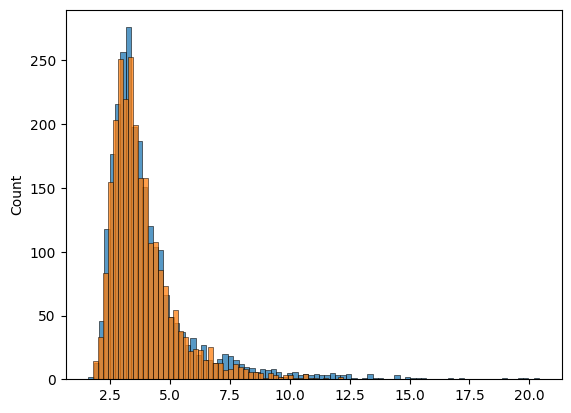

In [12]:
# n_bins = int((max(lenthes) - min(lenthes)) // 1)
sns.histplot(dataset['train']['duration'], ) #bins=n_bins
sns.histplot(dataset['test']['duration'], ) #bins=n_bins
plt.show()

In [13]:
from transformers import Wav2Vec2Model, Wav2Vec2FeatureExtractor

In [14]:
acoustic_preprocessor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-100k-voxpopuli")
acoustic_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-100k-voxpopuli")
acoustic_model = acoustic_model.requires_grad_(False).eval()

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

In [7]:
def preprocess_dataset(features):
    features['audio'] = acoustic_preprocessor(features['audio']['array'], sampling_rate=features['audio']['sampling_rate'], return_tensors="pt")
    features['audio'] = acoustic_model(**features['audio']).last_hidden_state
    return features

In [26]:
dataset['train'][0]

{'audio': {'path': '000010011.WAV',
  'array': array([-9.46044922e-04, -2.38037109e-03, -1.31225586e-03, ...,
         -9.15527344e-05,  3.05175781e-04, -2.44140625e-04]),
  'sampling_rate': 16000},
 'utt_accuracy': 8,
 'utt_completeness': 10.0,
 'utt_fluency': 9,
 'utt_prosodic': 9,
 'utt_total': 8,
 'words': "['WE', 'CALL', 'IT', 'BEAR']",
 'words_accuracy': '[10, 10, 10, 6]',
 'words_stress': '[10, 10, 10, 10]',
 'words_total': '[10, 10, 10, 6]',
 'phones': "[['W', 'IY0'], ['K', 'AO0', 'L'], ['IH0', 'T'], ['B', 'EH0', 'R']]",
 'phones_godness': '[[2.0, 2.0], [2.0, 1.8, 1.8], [2.0, 2.0], [2.0, 1.0, 1.0]]'}

In [38]:
ph_dict = []
for s in ['train', 'test']:
    for row in dataset[s]:
        phones = row['phones']
        phones = [ph for wph in phones for ph in wph]
        ph_dict.extend(phones)
ph_dict = set(ph_dict)

In [42]:
new_ph_dict = []
for ph in ph_dict:
    if ph[-1].isdigit():
        new_ph_dict.append(ph[:-1])
    else:
        new_ph_dict.append(ph)
new_ph_dict = set(new_ph_dict)

In [40]:
len(ph_dict)

67

In [43]:
new_ph_dict

{'AA',
 'AE',
 'AH',
 'AO',
 'AW',
 'AY',
 'B',
 'CH',
 'D',
 'DH',
 'EH',
 'ER',
 'EY',
 'F',
 'G',
 'HH',
 'IH',
 'IY',
 'JH',
 'K',
 'L',
 'M',
 'N',
 'NG',
 'OW',
 'OY',
 'P',
 'R',
 'S',
 'SH',
 'T',
 'TH',
 'UH',
 'UW',
 'V',
 'W',
 'Y',
 'Z',
 'ZH'}

In [44]:
len(new_ph_dict)

39

In [17]:
 x = ['AA0', 'AA1', 'AA2', 'AE0', 'AE1', 'AE2', 'AH0', 'AH1', 'AH2', 'AO0', 'AO1', 'AO2', 'AW0', 'AW1', 'AW2', 'AY0', 'AY1', 'AY2',
  'EH0', 'EH1', 'EH2', 'ER0', 'ER1', 'ER2', 'EY0', 'EY1', 'EY2', 'IH0', 'IH1', 'IH2', 'IY0', 'IY1', 'IY2', 'OW0', 'OW1', 'OW2', 
  'OY0', 'OY1', 'OY2', 'UH0', 'UH1', 'UH2', 'UW0', 'UW1', 'UW2', 'B', 'CH', 'D', 'DH', 'F', 'G', 'HH', 'JH', 'K', 'L', 'M', 'N', 'NG', 
  'P', 'R', 'S', 'SH', 'T', 'TH', 'V', 'W', 'Y', 'Z', 'ZH']

In [18]:
len(x)

69

In [28]:
import math
import warnings
import torch
import torch.nn as nn
import numpy as np

# code from the t2t-vit paper
def get_sinusoid_encoding(n_position, d_hid):
    ''' Sinusoid position encoding table '''

    def get_position_angle_vec(position):
        return [position / np.power(10000, 2 * (hid_j // 2) / d_hid) for hid_j in range(d_hid)]

    sinusoid_table = np.array([get_position_angle_vec(pos_i) for pos_i in range(n_position)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])  # dim 2i
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])  # dim 2i+1

    return torch.FloatTensor(sinusoid_table).unsqueeze(0)


def _no_grad_trunc_normal_(tensor, mean, std, a, b):
    # Cut & paste from PyTorch official master until it's in a few official releases - RW
    # Method based on https://people.sc.fsu.edu/~jburkardt/presentations/truncated_normal.pdf
    def norm_cdf(x):
        # Computes standard normal cumulative distribution function
        return (1. + math.erf(x / math.sqrt(2.))) / 2.

    if (mean < a - 2 * std) or (mean > b + 2 * std):
        warnings.warn("mean is more than 2 std from [a, b] in nn.init.trunc_normal_. "
                      "The distribution of values may be incorrect.",
                      stacklevel=2)

    with torch.no_grad():
        # Values are generated by using a truncated uniform distribution and
        # then using the inverse CDF for the normal distribution.
        # Get upper and lower cdf values
        l = norm_cdf((a - mean) / std)
        u = norm_cdf((b - mean) / std)

        # Uniformly fill tensor with values from [l, u], then translate to
        # [2l-1, 2u-1].
        tensor.uniform_(2 * l - 1, 2 * u - 1)

        # Use inverse cdf transform for normal distribution to get truncated
        # standard normal
        tensor.erfinv_()

        # Transform to proper mean, std
        tensor.mul_(std * math.sqrt(2.))
        tensor.add_(mean)

        # Clamp to ensure it's in the proper range
        tensor.clamp_(min=a, max=b)
        return tensor

def trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.):
    return _no_grad_trunc_normal_(tensor, mean, std, a, b)


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        # NOTE scale factor was wrong in my original version, can set manually to be compat with prev weights
        self.scale = qk_scale or head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape
        #print(C)
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]   # make torchscript happy (cannot use tensor as tuple)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):

    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(
            dim, num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale, attn_drop=attn_drop, proj_drop=drop)
        # NOTE: drop path for stochastic depth, we shall see if this is better than dropout here
        self.drop_path = nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x

# standard GOPT model proposed in the paper
class GOPT(nn.Module):
    def __init__(self, embed_dim, num_heads, depth, input_dim=84):
        super().__init__()
        self.input_dim = input_dim
        self.embed_dim = embed_dim
        # Transformer encode blocks
        self.blocks = nn.ModuleList([Block(dim=embed_dim, num_heads=num_heads) for i in range(depth)])

        # sin pos embedding or learnable pos embedding, 55 = 50 sequence length + 5 utt-level cls tokens
        #self.pos_embed = nn.Parameter(get_sinusoid_encoding(55, self.embed_dim) * 0.1, requires_grad=True)
        self.pos_embed = nn.Parameter(torch.zeros(1, 55, self.embed_dim))
        trunc_normal_(self.pos_embed, std=.02)

        # for phone classification
        self.in_proj = nn.Linear(self.input_dim, embed_dim)
        self.mlp_head_phn = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))

        # for word classification, 1=accuracy, 2=stress, 3=total
        self.mlp_head_word1 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.mlp_head_word2 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.mlp_head_word3 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))

        # canonical phone projection, assume there are 40 phns
        self.phn_proj = nn.Linear(40, embed_dim)

        # utterance level, 1=accuracy, 2=completeness, 3=fluency, 4=prosodic, 5=total score
        self.cls_token1 = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mlp_head_utt1 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.cls_token2 = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mlp_head_utt2 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.cls_token3 = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mlp_head_utt3 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.cls_token4 = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mlp_head_utt4 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))
        self.cls_token5 = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.mlp_head_utt5 = nn.Sequential(nn.LayerNorm(embed_dim), nn.Linear(embed_dim, 1))

        # initialize the cls tokens
        trunc_normal_(self.cls_token1, std=.02)
        trunc_normal_(self.cls_token2, std=.02)
        trunc_normal_(self.cls_token3, std=.02)
        trunc_normal_(self.cls_token4, std=.02)
        trunc_normal_(self.cls_token5, std=.02)

    # x shape in [batch_size, sequence_len, feat_dim]
    # phn in [batch_size, seq_len]
    def forward(self, x, phn):

        # batch size
        B = x.shape[0]

        # phn_one_hot in shape [batch_size, seq_len, feat_dim]
        phn_one_hot = torch.nn.functional.one_hot(phn.long()+1, num_classes=40).float()
        # phn_embed in shape [batch_size, seq_len, embed_dim]
        phn_embed = self.phn_proj(phn_one_hot)

        # if the input dimension is different from the Transformer embedding dimension, project the input to same dim
        if self.embed_dim != self.input_dim:
            x = self.in_proj(x)

        x = x + phn_embed

        cls_token1 = self.cls_token1.expand(B, -1, -1)
        cls_token2 = self.cls_token2.expand(B, -1, -1)
        cls_token3 = self.cls_token3.expand(B, -1, -1)
        cls_token4 = self.cls_token4.expand(B, -1, -1)
        cls_token5 = self.cls_token5.expand(B, -1, -1)

        x = torch.cat((cls_token1, cls_token2, cls_token3, cls_token4, cls_token5, x), dim=1)

        x = x + self.pos_embed

        # forward to the Transformer encoder
        for blk in self.blocks:
            x = blk(x)

        # the first 5 tokens are utterance-level cls tokens, i.e., accuracy, completeness, fluency, prosodic, total scores
        u1 = self.mlp_head_utt1(x[:, 0])
        u2 = self.mlp_head_utt2(x[:, 1])
        u3 = self.mlp_head_utt3(x[:, 2])
        u4 = self.mlp_head_utt4(x[:, 3])
        u5 = self.mlp_head_utt5(x[:, 4])

        # 6th-end tokens are phone score tokens
        p = self.mlp_head_phn(x[:, 5:])

        # word score is propagated to phone-level, so word output is also at phone-level.
        # but different mlp heads are used, 1 = accuracy, 2 = stress, 3 = total
        w1 = self.mlp_head_word1(x[:, 5:])
        w2 = self.mlp_head_word2(x[:, 5:])
        w3 = self.mlp_head_word3(x[:, 5:])
        return u1, u2, u3, u4, u5, p, w1, w2, w3

{'x': 2}

In [ ]:
import sys
import os
import time
import argparse

print("I am process %s, running on %s: starting (%s)" % (os.getpid(), os.uname()[1], time.asctime()))
parser = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter)
parser.add_argument("--exp-dir", type=str, default=os.getcwd()+"/exp/", help="directory to dump experiments")
parser.add_argument('--lr', '--learning-rate', default=1e-3, type=float, metavar='LR', help='initial learning rate')
parser.add_argument("--n-epochs", type=int, default=50, help="number of maximum training epochs")
parser.add_argument("--goptdepth", type=int, default=3, help="depth of gopt models")
parser.add_argument("--goptheads", type=int, default=1, help="heads of gopt models")
parser.add_argument("--batch_size", type=int, default=25, help="training batch size")
parser.add_argument("--embed_dim", type=int, default=24, help="gopt transformer embedding dimension")
parser.add_argument("--loss_w_phn", type=float, default=1, help="weight for phoneme-level loss")
parser.add_argument("--loss_w_word", type=float, default=1, help="weight for word-level loss")
parser.add_argument("--loss_w_utt", type=float, default=1, help="weight for utterance-level loss")
parser.add_argument("--model", type=str, default='gopt', help="name of the model")
parser.add_argument("--am", type=str, default='paiia', help="name of the acoustic models")
parser.add_argument("--noise", type=float, default=0., help="the scale of random noise added on the input GoP feature")

# just to generate the header for the result.csv
def gen_result_header():
    phn_header = ['epoch', 'phone_train_mse', 'phone_train_pcc', 'phone_test_mse', 'phone_test_pcc', 'learning rate']
    utt_header_set = ['utt_train_mse', 'utt_train_pcc', 'utt_test_mse', 'utt_test_pcc']
    utt_header_score = ['accuracy', 'completeness', 'fluency', 'prosodic', 'total']
    word_header_set = ['word_train_pcc', 'word_test_pcc']
    word_header_score = ['accuracy', 'stress', 'total']
    utt_header, word_header = [], []
    for dset in utt_header_set:
        utt_header = utt_header + [dset+'_'+x for x in utt_header_score]
    for dset in word_header_set:
        word_header = word_header + [dset+'_'+x for x in word_header_score]
    header = phn_header + utt_header + word_header
    return header

def train(audio_model, train_loader, test_loader, args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print('running on ' + str(device))

    # best_cum_mAP is checkpoint ensemble from the first epoch to the best epoch
    best_epoch, best_mse = 0, 999
    global_step, epoch = 0, 0
    exp_dir = args.exp_dir

    if not isinstance(audio_model, nn.DataParallel):
        audio_model = nn.DataParallel(audio_model)

    audio_model = audio_model.to(device)
    # Set up the optimizer
    trainables = [p for p in audio_model.parameters() if p.requires_grad]
    print('Total parameter number is : {:.3f} k'.format(sum(p.numel() for p in audio_model.parameters()) / 1e3))
    print('Total trainable parameter number is : {:.3f} k'.format(sum(p.numel() for p in trainables) / 1e3))
    optimizer = torch.optim.Adam(trainables, args.lr, weight_decay=5e-7, betas=(0.95, 0.999))

    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, list(range(10, 100, 5)), gamma=0.5, last_epoch=-1)

    loss_fn = nn.MSELoss()

    print("current #steps=%s, #epochs=%s" % (global_step, epoch))
    print("start training...")
    result = np.zeros([args.n_epochs, 32])

    while epoch < args.n_epochs:
        audio_model.train()
        for i, (audio_input, phn_label, phns, utt_label, word_label) in enumerate(train_loader):

            audio_input = audio_input.to(device, non_blocking=True)
            phn_label = phn_label.to(device, non_blocking=True)
            utt_label = utt_label.to(device, non_blocking=True)
            word_label = word_label.to(device, non_blocking=True)

            # warmup
            warm_up_step = 100
            if global_step <= warm_up_step and global_step % 5 == 0:
                warm_lr = (global_step / warm_up_step) * args.lr
                for param_group in optimizer.param_groups:
                    param_group['lr'] = warm_lr
                #print('warm-up learning rate is {:f}'.format(optimizer.param_groups[0]['lr']))

            # add random noise for augmentation.
            noise = (torch.rand([audio_input.shape[0], audio_input.shape[1], audio_input.shape[2]]) - 1) * args.noise
            noise = noise.to(device, non_blocking=True)
            audio_input = audio_input + noise

            #print(phns.shape)
            u1, u2, u3, u4, u5, p, w1, w2, w3 = audio_model(audio_input, phns)

            # filter out the padded tokens, only calculate the loss based on the valid tokens
            # < 0 is a flag of padded tokens
            mask = (phn_label>=0)
            p = p.squeeze(2)
            p = p * mask
            phn_label = phn_label * mask

            loss_phn = loss_fn(p, phn_label)

            # avoid the 0 losses of the padded tokens impacting the performance
            loss_phn = loss_phn * (mask.shape[0] * mask.shape[1]) / torch.sum(mask)

            # utterance level loss, also mse
            utt_preds = torch.cat((u1, u2, u3, u4, u5), dim=1)
            loss_utt = loss_fn(utt_preds ,utt_label)

            # word level loss
            word_label = word_label[:, :, 0:3]
            mask = (word_label>=0)
            word_pred = torch.cat((w1,w2,w3), dim=2)
            word_pred = word_pred * mask
            word_label = word_label * mask
            loss_word = loss_fn(word_pred, word_label)
            loss_word = loss_word * (mask.shape[0] * mask.shape[1] * mask.shape[2]) / torch.sum(mask)

            loss = args.loss_w_phn * loss_phn + args.loss_w_utt * loss_utt + args.loss_w_word * loss_word

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            global_step += 1

        print('start validation of epoch {:d}'.format(epoch))

        # ensemble results
        # don't save prediction for the training set
        tr_mse, tr_corr, tr_utt_mse, tr_utt_corr, tr_word_mse, tr_word_corr = validate(audio_model, train_loader, args, -1)
        te_mse, te_corr, te_utt_mse, te_utt_corr, te_word_mse, te_word_corr = validate(audio_model, test_loader, args, best_mse)

        print('Phone: Test MSE: {:.3f}, CORR: {:.3f}'.format(te_mse.item(), te_corr))
        print('Utterance:, ACC: {:.3f}, COM: {:.3f}, FLU: {:.3f}, PROC: {:.3f}, Total: {:.3f}'.format(te_utt_corr[0], te_utt_corr[1], te_utt_corr[2], te_utt_corr[3], te_utt_corr[4]))
        print('Word:, ACC: {:.3f}, Stress: {:.3f}, Total: {:.3f}'.format(te_word_corr[0], te_word_corr[1], te_word_corr[2]))

        result[epoch, :6] = [epoch, tr_mse, tr_corr, te_mse, te_corr, optimizer.param_groups[0]['lr']]

        result[epoch, 6:26] = np.concatenate([tr_utt_mse, tr_utt_corr, te_utt_mse, te_utt_corr])

        result[epoch, 26:32] = np.concatenate([tr_word_corr, te_word_corr])

        header = ','.join(gen_result_header())
        np.savetxt(exp_dir + '/result.csv', result, delimiter=',', header=header, comments='')
        print('-------------------validation finished-------------------')

        if te_mse < best_mse:
            best_mse = te_mse
            best_epoch = epoch

        if best_epoch == epoch:
            if os.path.exists("%s/models/" % (exp_dir)) == False:
                os.mkdir("%s/models" % (exp_dir))
            torch.save(audio_model.state_dict(), "%s/models/best_audio_model.pth" % (exp_dir))

        if global_step > warm_up_step:
            scheduler.step()

        #print('Epoch-{0} lr: {1}'.format(epoch, optimizer.param_groups[0]['lr']))
        epoch += 1

def validate(audio_model, val_loader, args, best_mse):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(audio_model, nn.DataParallel):
        audio_model = nn.DataParallel(audio_model)
    audio_model = audio_model.to(device)
    audio_model.eval()

    A_phn, A_phn_target = [], []
    A_u1, A_u2, A_u3, A_u4, A_u5, A_utt_target = [], [], [], [], [], []
    A_w1, A_w2, A_w3, A_word_target = [], [], [], []
    with torch.no_grad():
        for i, (audio_input, phn_label, phns, utt_label, word_label) in enumerate(val_loader):
            audio_input = audio_input.to(device)

            # compute output
            u1, u2, u3, u4, u5, p, w1, w2, w3 = audio_model(audio_input, phns)
            p = p.to('cpu').detach()
            u1, u2, u3, u4, u5 = u1.to('cpu').detach(), u2.to('cpu').detach(), u3.to('cpu').detach(), u4.to('cpu').detach(), u5.to('cpu').detach()
            w1, w2, w3 = w1.to('cpu').detach(), w2.to('cpu').detach(), w3.to('cpu').detach()

            A_phn.append(p)
            A_phn_target.append(phn_label)

            A_u1.append(u1)
            A_u2.append(u2)
            A_u3.append(u3)
            A_u4.append(u4)
            A_u5.append(u5)
            A_utt_target.append(utt_label)

            A_w1.append(w1)
            A_w2.append(w2)
            A_w3.append(w3)
            A_word_target.append(word_label)

        # phone level
        A_phn, A_phn_target  = torch.cat(A_phn), torch.cat(A_phn_target)

        # utterance level
        A_u1, A_u2, A_u3, A_u4, A_u5, A_utt_target = torch.cat(A_u1), torch.cat(A_u2), torch.cat(A_u3), torch.cat(A_u4), torch.cat(A_u5), torch.cat(A_utt_target)

        # word level
        A_w1, A_w2, A_w3, A_word_target = torch.cat(A_w1), torch.cat(A_w2), torch.cat(A_w3), torch.cat(A_word_target)

        # get the scores
        phn_mse, phn_corr = valid_phn(A_phn, A_phn_target)

        A_utt = torch.cat((A_u1, A_u2, A_u3, A_u4, A_u5), dim=1)
        utt_mse, utt_corr = valid_utt(A_utt, A_utt_target)

        A_word = torch.cat((A_w1, A_w2, A_w3), dim=2)
        word_mse, word_corr, valid_word_pred, valid_word_target = valid_word(A_word, A_word_target)

        if phn_mse < best_mse:
            print('new best phn mse {:.3f}, now saving predictions.'.format(phn_mse))

            # create the directory
            if os.path.exists(args.exp_dir + '/preds') == False:
                os.mkdir(args.exp_dir + '/preds')

            # saving the phn target, only do once
            if os.path.exists(args.exp_dir + '/preds/phn_target.npy') == False:
                np.save(args.exp_dir + '/preds/phn_target.npy', A_phn_target)
                np.save(args.exp_dir + '/preds/word_target.npy', valid_word_target)
                np.save(args.exp_dir + '/preds/utt_target.npy', A_utt_target)

            np.save(args.exp_dir + '/preds/phn_pred.npy', A_phn)
            np.save(args.exp_dir + '/preds/word_pred.npy', valid_word_pred)
            np.save(args.exp_dir + '/preds/utt_pred.npy', A_utt)

    return phn_mse, phn_corr, utt_mse, utt_corr, word_mse, word_corr

def valid_phn(audio_output, target):
    valid_token_pred = []
    valid_token_target = []
    audio_output = audio_output.squeeze(2)
    for i in range(audio_output.shape[0]):
        for j in range(audio_output.shape[1]):
            # only count valid tokens, not padded tokens (represented by negative values)
            if target[i, j] >= 0:
                valid_token_pred.append(audio_output[i, j])
                valid_token_target.append(target[i, j])
    valid_token_target = np.array(valid_token_target)
    valid_token_pred = np.array(valid_token_pred)

    valid_token_mse = np.mean((valid_token_target - valid_token_pred) ** 2)
    corr = np.corrcoef(valid_token_pred, valid_token_target)[0, 1]
    return valid_token_mse, corr

def valid_utt(audio_output, target):
    mse = []
    corr = []
    for i in range(5):
        cur_mse = np.mean(((audio_output[:, i] - target[:, i]) ** 2).numpy())
        cur_corr = np.corrcoef(audio_output[:, i], target[:, i])[0, 1]
        mse.append(cur_mse)
        corr.append(cur_corr)
    return mse, corr

def valid_word(audio_output, target):
    word_id = target[:, :, -1]
    target = target[:, :, 0:3]

    valid_token_pred = []
    valid_token_target = []

    # unique, counts = np.unique(np.array(target), return_counts=True)
    # print(dict(zip(unique, counts)))

    # for each utterance
    for i in range(target.shape[0]):
        prev_w_id = 0
        start_id = 0
        # for each token
        for j in range(target.shape[1]):
            cur_w_id = word_id[i, j].int()
            # if a new word
            if cur_w_id != prev_w_id:
                # average each phone belongs to the word
                valid_token_pred.append(np.mean(audio_output[i, start_id: j, :].numpy(), axis=0))
                valid_token_target.append(np.mean(target[i, start_id: j, :].numpy(), axis=0))
                # sanity check, if the range indeed contains a single word
                if len(torch.unique(target[i, start_id: j, 1])) != 1:
                    print(target[i, start_id: j, 0])
                # if end of the utterance
                if cur_w_id == -1:
                    break
                else:
                    prev_w_id = cur_w_id
                    start_id = j

    valid_token_pred = np.array(valid_token_pred)
    # this rounding is to solve the precision issue in the label
    valid_token_target = np.array(valid_token_target).round(2)

    mse_list, corr_list = [], []
    # for each (accuracy, stress, total) word score
    for i in range(3):
        valid_token_mse = np.mean((valid_token_target[:, i] - valid_token_pred[:, i]) ** 2)
        corr = np.corrcoef(valid_token_pred[:, i], valid_token_target[:, i])[0, 1]
        mse_list.append(valid_token_mse)
        corr_list.append(corr)
    return mse_list, corr_list, valid_token_pred, valid_token_target

In [ ]:
args = parser.parse_args(args=[])

if torch.cuda.is_available() == False:
    raise ValueError('GPU is not enabled. Please go to top menu - edit - notebook settings -hardware accelerator - GPU')

am = args.am
print('now train with {:s} acoustic models'.format(am))
feat_dim = {'librispeech':84, 'paiia':86, 'paiib': 88}
input_dim=feat_dim[am]

# nowa is the best models used in this work
if args.model == 'gopt':
    print('now train a GOPT models')
    audio_mdl = GOPT(embed_dim=args.embed_dim, num_heads=args.goptheads, depth=args.goptdepth, input_dim=input_dim)

tr_dataset = GoPDataset('train', am=am)
tr_dataloader = DataLoader(tr_dataset, batch_size=args.batch_size, shuffle=True)
te_dataset = GoPDataset('test', am=am)
te_dataloader = DataLoader(te_dataset, batch_size=2500, shuffle=False)

if os.path.exists(args.exp_dir) == False:
  os.makedirs(args.exp_dir)
train(audio_mdl, tr_dataloader, te_dataloader, args)